2022-07-15 14:44:41.963007: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1 
Test Set AUC Score for the ROC Curve: 0.6077890573105529


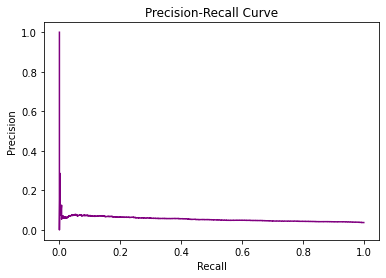

2022-07-15 14:46:19.649363: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2 
Test Set AUC Score for the ROC Curve: 0.597768503696928


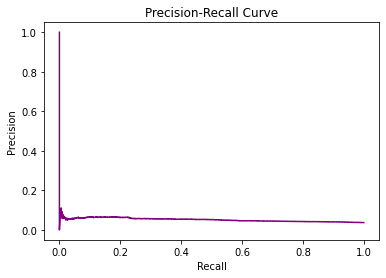

2022-07-15 14:47:55.509372: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3 
Test Set AUC Score for the ROC Curve: 0.6002013709668638


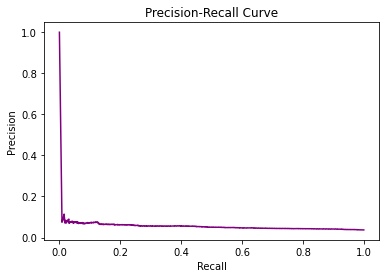

2022-07-15 14:49:19.331508: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4 
Test Set AUC Score for the ROC Curve: 0.5731680332777978


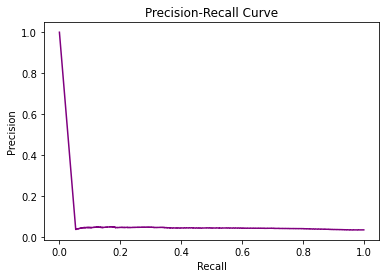

In [8]:
import destruction_models as models
from tensorflow.keras import callbacks, metrics
from tensorflow.keras.utils import Sequence
from destruction_utilities import *
import matplotlib.pyplot as plt
import tensorflow as tf
import time
import pickle
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score, precision_score, recall_score

from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC

CITY = 'aleppo'
BATCH_SIZE = 32


test_images_t0 = read_zarr(CITY, 'images_siamese_test_t0')
test_images_tt = read_zarr(CITY, 'images_siamese_test_tt')
test_labels = read_zarr(CITY, 'labels_siamese_valid')


class SiameseTestGenerator(Sequence):
    def __init__(self, images, batch_size=BATCH_SIZE):
        self.images_t0 = images[0]
        self.images_tt = images[1]
        self.batch_size = batch_size

    def __len__(self):
        return len(self.images_t0)//self.batch_size
    
    def __getitem__(self, index):
        
        if(index == self.__len__()-1):
            X_t0 = self.images_t0[index*self.batch_size:len(self.images_t0)]
            X_tt = self.images_tt[index*self.batch_size:len(self.images_t0)]
        else:
            X_t0 = self.images_t0[index*self.batch_size:(index+1)*self.batch_size]          
            X_tt = self.images_tt[index*self.batch_size:(index+1)*self.batch_size]          
    
        
        return {'images_t0':X_t0, 'images_tt':X_tt}



for i in range(0, 4):
    model_path = f'../models/{CITY}/snn/run_{i}'
    best_model = load_model(model_path, custom_objects={'auc':metrics.AUC(num_thresholds=200, curve='ROC', name='auc')})
    test_generator = SiameseTestGenerator((test_images_t0, test_images_tt))
    yhat_proba, y = np.squeeze(best_model.predict(test_generator)[0:test_labels[:].shape[0]]), np.squeeze(test_labels[:])
    roc_auc_test = roc_auc_score(y, yhat_proba)
    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)


    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i+1} \nTest Set AUC Score for the ROC Curve: {roc_auc_test}' )
    #display plot
    plt.show()

2022-07-15 06:31:02.164712: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 0
Test Set AUC Score for the ROC Curve: 0.803361672819139


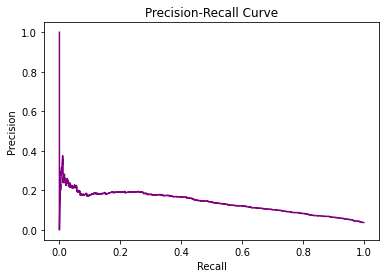

2022-07-15 06:34:20.500237: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 1
Test Set AUC Score for the ROC Curve: 0.7854660633976893


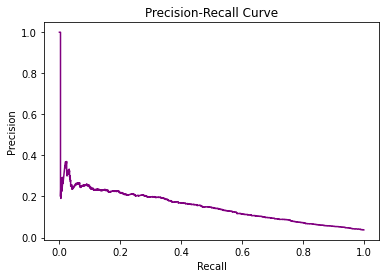

2022-07-15 06:37:41.307272: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 2
Test Set AUC Score for the ROC Curve: 0.807996744089815


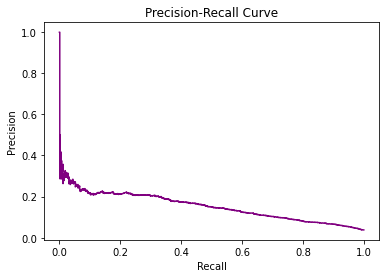

2022-07-15 06:41:21.801250: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 3
Test Set AUC Score for the ROC Curve: 0.8087411660296409


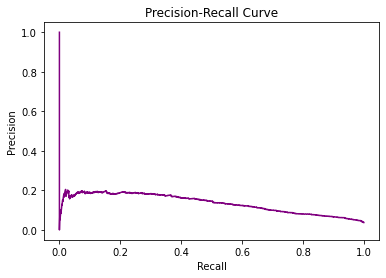

2022-07-15 06:46:22.748165: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


Run 4
Test Set AUC Score for the ROC Curve: 0.8028064257946491


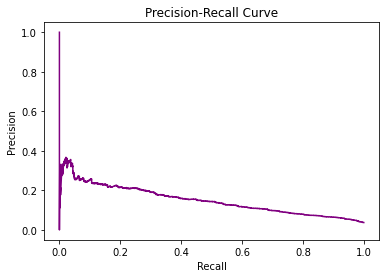

In [5]:
# Modules
import numpy as np
import pandas as pd
import itertools
import destruction_models as models
import tensorflow as tf
import random

from destruction_utilities import *
from destruction_statistics import *
from numpy import random
import matplotlib.pyplot as plt
from tensorflow.keras import callbacks, preprocessing
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import CategoricalAccuracy, Precision, AUC
from tensorflow.keras.models import load_model
from sklearn.metrics import precision_recall_curve, roc_auc_score

from os import path
import zarr
import shutil
import gc
import time
import pickle

# from tensorflow.keras import layers, models, Sequential

CITY='aleppo'

test_images = read_zarr(CITY, 'images_conv_test')
test_labels = read_zarr(CITY, 'labels_conv_test')

auc = AUC(
    num_thresholds=200,
    curve='ROC',
    name="auc"
)

class CNNTestGenerator(Sequence):
    def __init__(self, images, batch_size=32):
        self.images = images
        self.batch_size = batch_size
        
    def __len__(self):
        return len(self.images)//self.batch_size
    
    def __getitem__(self, index):
        if(index == self.__len__()-1):
            X = self.images[index*self.batch_size:len(self.images)]
        else:
            X = self.images[index*self.batch_size:(index+1)*self.batch_size]            
        return X
    
    def augment(self, X):        
        # Brightness
        alpha = random.choice(np.linspace(0.85, 1.4))
        X = X * alpha
        
        return X

for i in range(0,5):
    model_path = f'../models/{CITY}/cnn/run_{i}'
    best_model = load_model(model_path, custom_objects={'f1_m':f1_m, 'precision_m': precision_m, 'recall_m': recall_m, 'auc': auc})
    test_generator = CNNTestGenerator(test_images)

    yhat_proba, y = np.squeeze(best_model.predict(test_generator)), np.squeeze(test_labels[:])

    roc_auc_test = roc_auc_score(y, yhat_proba)

    #calculate precision and recall
    precision, recall, thresholds = precision_recall_curve(y, yhat_proba)

    #create precision recall curve
    fig, ax = plt.subplots()
    ax.plot(recall, precision, color='purple')

    #add axis labels to plot
    ax.set_title('Precision-Recall Curve')
    ax.set_ylabel('Precision')
    ax.set_xlabel('Recall')

    print(f'Run {i}\nTest Set AUC Score for the ROC Curve: {roc_auc_test}' )

    #display plot
    plt.show()